### Single-qubit randomized benchmarking with a coherent $Z$ error

Every Clifford is built out of **one physical pulse shape**: a $\pi/2$ rotation about an
axis in the equatorial plane. The only knob is the phase of the drive,

$$R(\varphi) \;=\; \exp\!\left[-i\,\frac{\pi/2}{2}\,\big(\cos\varphi\,\sigma_x + \sin\varphi\,\sigma_y\big)\right],$$

so that

$$X_{\pi/2} = R(0), \qquad Y_{\pi/2} = R(\pi/2), \qquad X_\pi = R(0)\,R(0), \qquad Y_\pi = R(\pi/2)\,R(\pi/2).$$

The non-ideality: **after every physical pulse** the qubit picks up the *same* fixed phase
error, a rotation about $z$ by an angle $\Phi$,

$$Z(\Phi) = \exp\!\left[-i\,\frac{\Phi}{2}\,\sigma_z\right],$$

so the gate that is actually applied is $\tilde{G} = Z(\Phi)\,G$. This is coherent and
systematic — there is **no decoherence anywhere in this notebook**.

A sequence of $m$ random Cliffords followed by the recovery Clifford is

$$U \;=\; \tilde{C}_{\rm inv}\,\tilde{C}_m \cdots \tilde{C}_2\,\tilde{C}_1 ,$$

and the measured quantity is the return (survival) probability

$$P(m) \;=\; \big|\langle 0 | U | 0 \rangle\big|^2 .$$

For $\Phi = 0$ the recovery is exact and $P(m) = 1$ for every $m$. For $\Phi \neq 0$ the
errors accumulate and $P(m)$ is no longer constant.

#### Notation

| symbol | code name | meaning |
|---|---|---|
| $\varphi$ | `phase` | phase of the drive, i.e. the axis of the $\pi/2$ pulse in the $xy$-plane |
| $R(\varphi)$ | `X90`, `Y90` | the two physical pulses, $\varphi = 0$ and $\varphi = \pi/2$ |
| $\Phi$ | `PHI`, `phi` | fixed coherent $Z$ error angle applied after every physical pulse (rad) |
| $Z(\Phi)$ | `z_error` | the error rotation $\exp[-i\Phi\sigma_z/2]$ |
| $C_i$ | `clifford_list[i]["U"]` | the $i$-th of the 24 single-qubit Cliffords (ideal) |
| — | `clifford_list[i]["pulses"]` | the list of physical pulses that make up $C_i$ |
| $C_{\rm inv}$ | `recovery` | Clifford that inverts the ideal product of the random sequence |
| $m$ | `m`, `LENGTHS` | number of random Cliffords in the sequence |
| $K$ | `N_SEQUENCES` | number of random sequences averaged at each $m$ |
| $U$ | `U` | total propagator of one sequence, including all errors |
| $P(m)$ | `p_return` | return probability $|\langle 0|U|0\rangle|^2$ |

In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

#### 1. The physical pulses and the error

$$R(\varphi) = \exp\!\left[-i\,\frac{\pi}{4}\big(\cos\varphi\,\sigma_x + \sin\varphi\,\sigma_y\big)\right],
\qquad
Z(\Phi) = \exp\!\left[-i\,\frac{\Phi}{2}\,\sigma_z\right]$$

In [2]:
def pi_half_pulse(phase):
    """pi/2 rotation about the axis (cos(phase), sin(phase), 0)."""
    # generator: (cos(phi) sigma_x + sin(phi) sigma_y) / 2
    axis = np.cos(phase) * qt.sigmax() + np.sin(phase) * qt.sigmay()
    # R(phi) = exp[-i (pi/2) (axis)/2 ] = exp[-i pi/4 axis]
    return (-1j * (np.pi / 4) * axis).expm()


def z_rotation(angle):
    """Rotation about z by `angle`:  Z(angle) = exp[-i angle sigma_z / 2]."""
    return (-1j * (angle / 2) * qt.sigmaz()).expm()


# The only two pulses we are ever allowed to play.
X90 = pi_half_pulse(0.0)           # X/2, drive phase 0
Y90 = pi_half_pulse(np.pi / 2)     # Y/2, the same pulse with 90 degrees of phase

PULSES = {"X/2": X90, "Y/2": Y90}

ket0 = qt.basis(2, 0)              # |0>, the state we prepare and measure

print("X/2 =")
print(np.round(X90.full(), 4))
print("Y/2 =")
print(np.round(Y90.full(), 4))

X/2 =
[[0.7071+0.j     0.    -0.7071j]
 [0.    -0.7071j 0.7071+0.j    ]]
Y/2 =
[[ 0.7071+0.j -0.7071+0.j]
 [ 0.7071+0.j  0.7071+0.j]]


#### 2. Build the 24 single-qubit Cliffords out of $X_{\pi/2}$ and $Y_{\pi/2}$

Two unitaries are the same gate if they differ only by a global phase, so we compare
matrices after dividing out that phase. Starting from the identity we keep multiplying by
$X_{\pi/2}$ and $Y_{\pi/2}$ (breadth first, so each Clifford gets the *shortest* pulse
sequence) until no new gates appear. There are exactly 24.

In [3]:
def phase_free_key(U):
    """Hashable label for a 2x2 unitary, insensitive to a global phase e^{i alpha}."""
    M = U.full()
    for z in M.ravel():
        if abs(z) > 1e-9:
            M = M * (abs(z) / z)   # divide out e^{i arg(z)} of the first nonzero entry
            break
    return tuple(np.round(M.ravel(), 6))


clifford_list = []          # each entry: {"U": ideal unitary, "pulses": list of pulse names}
index_of = {}               # phase_free_key(U) -> position in clifford_list

# seed the search with the identity (empty pulse sequence)
identity = qt.qeye(2)
clifford_list.append({"U": identity, "pulses": []})
index_of[phase_free_key(identity)] = 0

frontier = [(identity, [])]
while frontier:
    next_frontier = []
    for U, pulses in frontier:
        for name in PULSES:
            U_new = PULSES[name] * U        # play `name` after everything so far
            pulses_new = pulses + [name]
            key = phase_free_key(U_new)
            if key not in index_of:
                index_of[key] = len(clifford_list)
                clifford_list.append({"U": U_new, "pulses": pulses_new})
                next_frontier.append((U_new, pulses_new))
    frontier = next_frontier

print("number of Cliffords found:", len(clifford_list))

lengths = []
for c in clifford_list:
    lengths.append(len(c["pulses"]))
print("pulses per Clifford:", sorted(set(lengths)))
print("average pulses per Clifford:", np.mean(lengths))

for c in clifford_list[:6]:
    print(c["pulses"])

number of Cliffords found: 24
pulses per Clifford: [0, 1, 2, 3, 4, 5]
average pulses per Clifford: 3.0833333333333335
[]
['X/2']
['Y/2']
['X/2', 'X/2']
['X/2', 'Y/2']
['Y/2', 'X/2']


#### 3. One randomized-benchmarking sequence

1. draw $m$ Cliffords at random and keep track of their **ideal** product
   $C_m \cdots C_1$;
2. look up the Clifford $C_{\rm inv}$ equal to $(C_m \cdots C_1)^\dagger$ and append it;
3. replay the whole thing as physical pulses, inserting the error $Z(\Phi)$ after each one:

$$U \;=\; \prod_{\text{pulses, in time order}} Z(\Phi)\, R(\varphi_k)
\qquad\Longrightarrow\qquad
P = \big|\langle 0|U|0\rangle\big|^2 .$$

In [4]:
def run_sequence(m, phi, rng):
    """Return probability of one random sequence of m Cliffords + recovery."""
    U_ideal = qt.qeye(2)     # ideal product C_m ... C_1, used only to find the recovery
    pulses = []              # physical pulses actually played, in time order

    for k in range(m):
        i = rng.integers(len(clifford_list))
        U_ideal = clifford_list[i]["U"] * U_ideal      # C_i applied after what came before
        pulses = pulses + clifford_list[i]["pulses"]

    # Recovery: the Clifford equal to (C_m ... C_1)^dagger. It is chosen from the IDEAL
    # product only -- this is the gate we would apply believing our gates were perfect,
    # so it knows nothing about Phi and does not undo the error.
    recovery = index_of[phase_free_key(U_ideal.dag())]
    pulses = pulses + clifford_list[recovery]["pulses"]

    # actual evolution: every pulse is followed by the same fixed Z error
    z_error = z_rotation(phi)
    U = qt.qeye(2)
    for name in pulses:
        U = z_error * PULSES[name] * U                 # U <- Z(Phi) R(phi_k) U

    amplitude = ket0.overlap(U * ket0)                 # <0|U|0>
    return abs(amplitude) ** 2


def survival_curve(lengths, phi, seed):
    """Return probability averaged over N_SEQUENCES random sequences, for each length."""
    rng = np.random.default_rng(seed)
    curve = []
    for m in lengths:
        probabilities = []
        for s in range(N_SEQUENCES):
            probabilities.append(run_sequence(m, phi, rng))
        curve.append(np.mean(probabilities))
    return np.array(curve)

#### 4. Parameters

`PHI` is the coherent $Z$ error per pulse. It defaults to zero — the ideal, error-free
experiment.

In [5]:
PHI = 0.0                # coherent Z error per pulse, in radians (0 = ideal)
N_SEQUENCES = 20         # random sequences averaged at each length
SEED = 12345             # random seed, so every error angle sees the same sequences

LENGTHS = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1000, 1500, 2000]

#### 5. Ideal simulation: $\Phi = 0$

With no error the recovery Clifford undoes the sequence exactly, so $P(m) = 1$ for all $m$.

In [6]:
p_ideal = survival_curve(LENGTHS, PHI, SEED)

for m, p in zip(LENGTHS, p_ideal):
    print(f"m = {m:5d}   P = {p:.12f}")

m =     1   P = 1.000000000000
m =     2   P = 1.000000000000
m =     4   P = 1.000000000000
m =     8   P = 1.000000000000
m =    16   P = 1.000000000000
m =    32   P = 1.000000000000
m =    64   P = 1.000000000000
m =   128   P = 1.000000000000
m =   256   P = 1.000000000000
m =   512   P = 1.000000000000
m =  1000   P = 1.000000000000
m =  1500   P = 1.000000000000
m =  2000   P = 0.999999999999


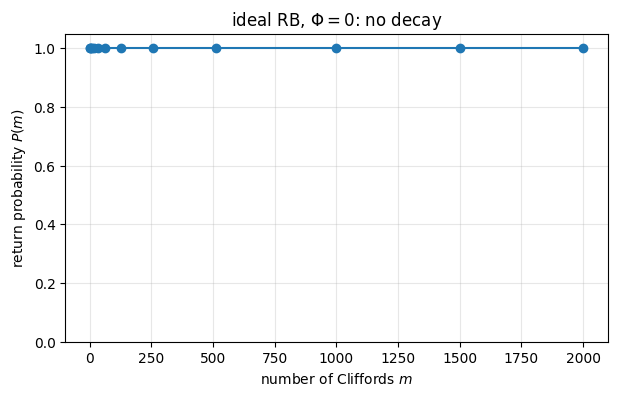

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(LENGTHS, p_ideal, "o-")
plt.xlabel("number of Cliffords $m$")
plt.ylabel(r"return probability $P(m)$")
plt.title(r"ideal RB, $\Phi = 0$: no decay")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.show()

#### 6. With the fixed coherent $Z$ error

Now give the error a nonzero value. The same $Z(\Phi)$ is applied after every physical
pulse, so the error is fully coherent and systematic; still no decoherence. The return
probability is no longer constant in $m$.

In [8]:
PHI_DEG_LIST = [0.0, 5.0, 10.0, 20.0]    # error angles to compare, in degrees

curves = []
for phi_deg in PHI_DEG_LIST:
    phi = np.deg2rad(phi_deg)            # Phi in radians
    curves.append(survival_curve(LENGTHS, phi, SEED))
    print(f"Phi = {phi_deg:5.1f} deg done")

print()
header = "    m  " 
for phi_deg in PHI_DEG_LIST:
    header = header + f"  {phi_deg:6.1f} deg"
print(header)
for row, m in enumerate(LENGTHS):
    line = f"{m:5d}  "
    for curve in curves:
        line = line + f"  {curve[row]:10.4f}"
    print(line)

Phi =   0.0 deg done


Phi =   5.0 deg done


Phi =  10.0 deg done


Phi =  20.0 deg done

    m       0.0 deg     5.0 deg    10.0 deg    20.0 deg
    1        1.0000      1.0000      0.9997      0.9961
    2        1.0000      1.0000      0.9995      0.9928
    4        1.0000      1.0000      0.9992      0.9878
    8        1.0000      0.9999      0.9985      0.9766
   16        1.0000      0.9999      0.9979      0.9665
   32        1.0000      0.9998      0.9966      0.9501
   64        1.0000      0.9993      0.9892      0.8468
  128        1.0000      0.9989      0.9832      0.7798
  256        1.0000      0.9978      0.9654      0.6429
  512        1.0000      0.9946      0.9190      0.5464
 1000        1.0000      0.9922      0.8868      0.5620
 1500        1.0000      0.9858      0.8191      0.5469
 2000        1.0000      0.9852      0.8031      0.5199


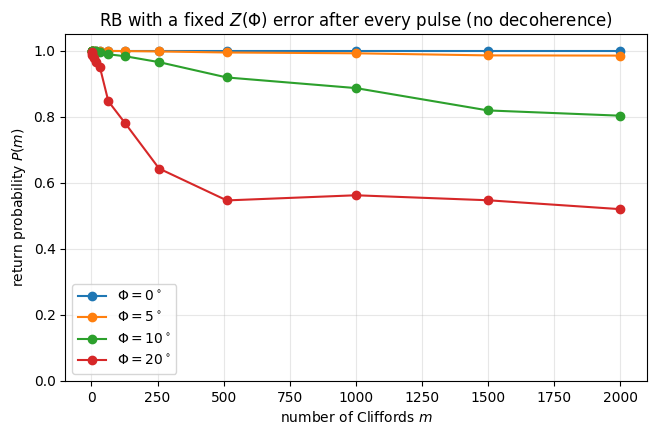

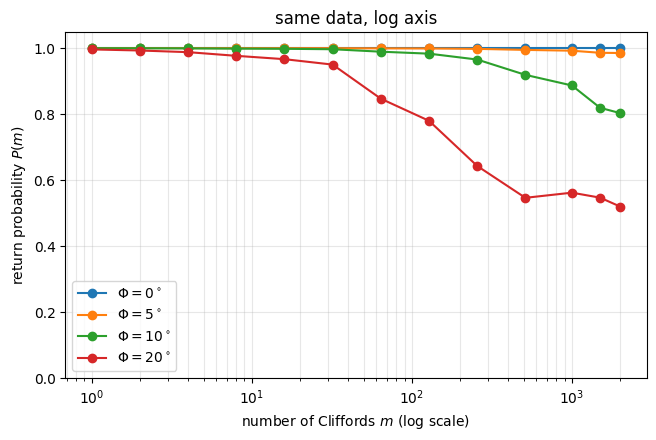

In [9]:
plt.figure(figsize=(7.5, 4.5))
for phi_deg, curve in zip(PHI_DEG_LIST, curves):
    plt.plot(LENGTHS, curve, "o-", label=rf"$\Phi = {phi_deg:g}^\circ$")
plt.xlabel("number of Cliffords $m$")
plt.ylabel(r"return probability $P(m)$")
plt.title(r"RB with a fixed $Z(\Phi)$ error after every pulse (no decoherence)")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7.5, 4.5))
for phi_deg, curve in zip(PHI_DEG_LIST, curves):
    plt.semilogx(LENGTHS, curve, "o-", label=rf"$\Phi = {phi_deg:g}^\circ$")
plt.xlabel("number of Cliffords $m$ (log scale)")
plt.ylabel(r"return probability $P(m)$")
plt.title("same data, log axis")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()

#### 7. Fidelity of the noisy $X_{\pi/2}$ gate

The gate we actually play is the ideal $X_{\pi/2}$ followed by the fixed phase error,

$$\tilde{G} = Z(\Phi)\,X_{\pi/2}, \qquad\text{target}\quad G = X_{\pi/2},$$

so what is left over after the ideal gate is the error operator

$$E \;=\; \tilde{G}\,G^\dagger \;=\; Z(\Phi)\,X_{\pi/2}\,X_{\pi/2}^\dagger \;=\; Z(\Phi).$$

For a unitary error in dimension $d$ the **average gate fidelity** and the **process
(entanglement) fidelity** are

$$F_{\rm avg} = \frac{d + |\mathrm{Tr}\,E|^2}{d\,(d+1)},
\qquad
F_{\rm pro} = \frac{|\mathrm{Tr}\,E|^2}{d^2},$$

which for a qubit ($d = 2$) are $F_{\rm avg} = (2 + |\mathrm{Tr}\,E|^2)/6$ and
$F_{\rm pro} = |\mathrm{Tr}\,E|^2/4$.

Here $\mathrm{Tr}\,E = \mathrm{Tr}\,Z(\Phi) = 2\cos(\Phi/2)$, so there is a closed form to
check the numbers against:

$$F_{\rm avg} = \frac{2 + 4\cos^2(\Phi/2)}{6} = 1 - \frac{2}{3}\sin^2\!\left(\frac{\Phi}{2}\right).$$

This is the fidelity of a **single** pulse. It is the per-pulse quantity; it is *not* the RB
decay rate above, because the $Z$ errors partially echo each other out inside each Clifford.

In [37]:
def average_gate_fidelity(actual, target):
    """F_avg = (d + |Tr E|^2) / (d(d+1)) for a unitary error E = actual . target^dagger."""
    d = 2
    E = actual * target.dag()                  # error left over after the ideal gate
    trace = E.tr()                             # Tr[E]
    return (d + abs(trace) ** 2) / (d * (d + 1))


def process_fidelity(actual, target):
    """F_pro = |Tr E|^2 / d^2 for a unitary error E = actual . target^dagger."""
    d = 2
    E = actual * target.dag()
    return abs(E.tr()) ** 2 / d ** 2


target_gate = X90                              # the ideal X/2 we are trying to play

print("  Phi (deg)        F_avg      F_process      1 - F_avg    closed form")
for phi_deg in PHI_DEG_LIST:
    phi = np.deg2rad(phi_deg)
    actual_gate = z_rotation(phi) * X90        # what we really play: Z(Phi) X/2
    f_avg = average_gate_fidelity(actual_gate, target_gate)
    f_pro = process_fidelity(actual_gate, target_gate)
    # closed form: E = Z(Phi), Tr E = 2 cos(Phi/2)  =>  F_avg = 1 - (2/3) sin^2(Phi/2)
    f_closed = 1 - (2 / 3) * np.sin(phi / 2) ** 2
    print(f"{phi_deg:9.1f}  {f_avg:13.8f}  {f_pro:11.8f}  {1 - f_avg:13.3e}  {f_closed:13.8f}")

  Phi (deg)        F_avg      F_process      1 - F_avg    closed form
      0.0     1.00000000   1.00000000      0.000e+00     1.00000000
      0.3     0.99999543   0.99999315      4.569e-06     0.99999543
      1.0     0.99994923   0.99992385      5.077e-05     0.99994923
      3.0     0.99954318   0.99931477      4.568e-04     0.99954318
      5.0     0.99873157   0.99809735      1.268e-03     0.99873157
     10.0     0.99493592   0.99240388      5.064e-03     0.99493592


max |numerical - closed form| = 5.551115123125783e-16


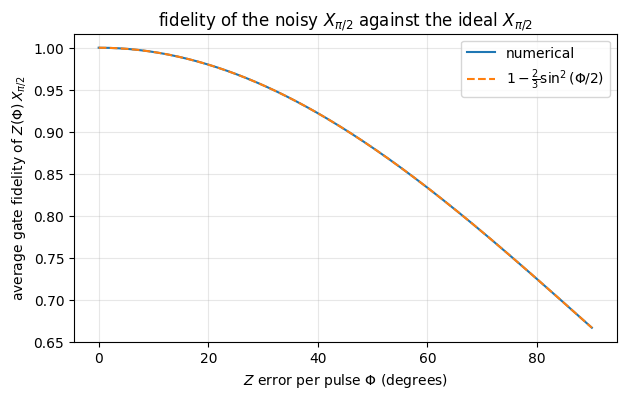

In [38]:
# sweep Phi and compare the numerical fidelity against the closed form
phi_scan = np.linspace(0.0, np.pi / 2, 200)    # 0 to 90 degrees of Z error per pulse

f_numerical = []
for phi in phi_scan:
    actual_gate = z_rotation(phi) * X90
    f_numerical.append(average_gate_fidelity(actual_gate, target_gate))
f_numerical = np.array(f_numerical)

f_closed = 1 - (2 / 3) * np.sin(phi_scan / 2) ** 2      # 1 - (2/3) sin^2(Phi/2)
print("max |numerical - closed form| =", np.max(np.abs(f_numerical - f_closed)))

plt.figure(figsize=(7, 4))
plt.plot(np.rad2deg(phi_scan), f_numerical, label="numerical")
plt.plot(np.rad2deg(phi_scan), f_closed, "--", label=r"$1 - \frac{2}{3}\sin^2(\Phi/2)$")
plt.xlabel(r"$Z$ error per pulse $\Phi$ (degrees)")
plt.ylabel(r"average gate fidelity of $Z(\Phi)\,X_{\pi/2}$")
plt.title(r"fidelity of the noisy $X_{\pi/2}$ against the ideal $X_{\pi/2}$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()